# Topography Correction



Here, we show how to use 'harmonica' https://www.fatiando.org/harmonica/latest/ to remove topography effect

See https://www.fatiando.org/harmonica/latest/user_guide/topographic_correction.html for more information

In [1]:
# Load necessary package 
import harmonica as hm
import pandas as pd
import pyproj
import matplotlib.pyplot as plt
import numpy as np
import verde as vd

C:\Users\li353\AppData\Local\miniforge3\envs\cage\lib\site-packages\verde\datasets\sample_data.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Read in Free Air Gravity Disturbance after normal earth correction

In [2]:
#Read in Gravity data after drift correction
Data = pd.read_csv('Free_Air_Grav_CAGE_FIELD.csv', delimiter=r',')

In [3]:
# Let's look few line of the data
Data.head()

,Name,Lon,Lat,Height_Ellipsoid,Total Gravity,Free Air Disturbance
0,L1_S100,116.215892,-31.521237,218.952,-0.766230,-0.674237
1,L1_S200,116.214864,-31.521183,216.100,0.020231,-0.763659
2,L1_S300,116.213828,-31.521228,211.371,0.737294,-1.509716
3,L1_S400,116.212786,-31.521207,210.479,0.717150,-1.803505
4,L1_S500,116.211679,-31.521218,211.715,0.249746,-1.890320


# Topography correction

We need to remove the 3D topography mass from the Free Air disturbance. Here we use DEM from global topography grid to do that. You could use high resolution topography grid in your own study area.

Important: Remember to match the topography resolution with gravity

In [4]:
import rasterio

In [5]:
# Load topography grid
import xarray as xr
topography = xr.load_dataarray('dem_50m_wgs84.tif')


In [6]:
topography

<xarray.DataArray 'band_data' (band: 1, y: 1475, x: 1438)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * band         (band) int32 4B 1
  * x            (x) float64 12kB 115.9 115.9 115.9 115.9 ... 116.6 116.6 116.6
  * y            (y) float64 12kB -31.18 -31.18 -31.18 ... -31.88 -31.88 -31.88
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

In [7]:
Data

,Name,Lon,Lat,Height_Ellipsoid,Total Gravity,Free Air Disturbance
0,L1_S100,116.215892,-31.521237,218.952,-0.766230,-0.674237
1,L1_S200,116.214864,-31.521183,216.100,0.020231,-0.763659
2,L1_S300,116.213828,-31.521228,211.371,0.737294,-1.509716
3,L1_S400,116.212786,-31.521207,210.479,0.717150,-1.803505
4,L1_S500,116.211679,-31.521218,211.715,0.249746,-1.890320
...,...,...,...,...,...,...
57,L9_S200,116.214863,-31.513597,225.150,-2.261085,0.358826
58,L9_S300,116.213867,-31.513592,228.460,-3.482005,0.159895
59,L9_S400,116.212816,-31.513737,232.575,-4.346265,0.553982
60,L9_S500,116.211697,-31.513624,236.200,-6.013016,0.015081


In [8]:
# Let's crop it to the gravity region (slightly larger):
region = vd.get_region((Data.Lon[0], Data.Lat[0]))
region_pad = vd.pad_region(region, pad=0.1)

topography = topography[0].sel(
    x=slice(region_pad[0], region_pad[1]),
    y=slice(region_pad[3], region_pad[2]),
)
topography

<xarray.DataArray 'band_data' (y: 420, x: 420)> Size: 706kB
array([[169.66444, 163.18459, 160.07597, ..., 313.77307, 311.94202,
        309.90323],
       [171.41502, 169.23386, 166.1752 , ..., 311.18115, 309.88223,
        308.31943],
       [173.06645, 169.23386, 166.1752 , ..., 307.78455, 309.959  ,
        308.24075],
       ...,
       [217.04482, 223.90816, 233.51222, ..., 272.3302 , 270.57346,
        271.92465],
       [213.64148, 220.10931, 234.06575, ..., 276.40747, 275.57678,
        277.1345 ],
       [200.67834, 206.6303 , 229.23378, ..., 281.75357, 279.71512,
        278.8308 ]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 3kB 116.1 116.1 116.1 116.1 ... 116.3 116.3 116.3
  * y            (y) float64 3kB -31.42 -31.42 -31.42 ... -31.62 -31.62 -31.62
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

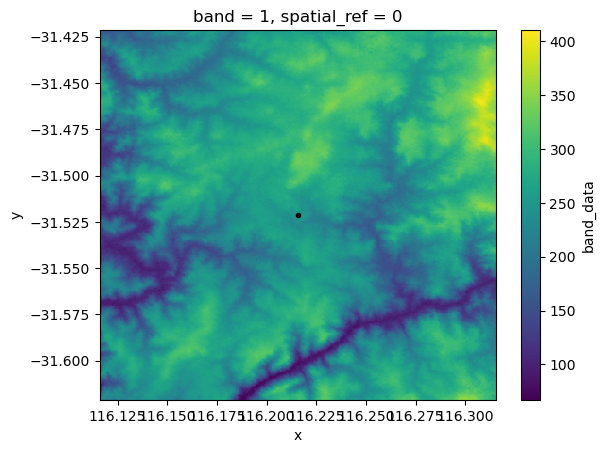

In [10]:
topography.plot()
plt.plot(Data['Lon'][0], Data['Lat'][0],'k.')

# Projection

Right now everything is in Geographic coordinate system (longtidude and latitude), in small scales, projection system in meters will be easier to handle. So here, we use EPSG:28350

In [11]:
# Define the projection
projection = pyproj.Proj('EPSG:28350')

# Project the topography grid use verde
topography_proj = vd.project_grid(topography.dropna(dim='x').dropna(dim='y'), projection, method="nearest")
topography_proj


<xarray.DataArray 'band_data' (northing: 420, easting: 420)> Size: 706kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * easting   (easting) float64 3kB 4.16e+05 4.16e+05 ... 4.35e+05 4.351e+05
  * northing  (northing) float64 3kB 6.501e+06 6.501e+06 ... 6.523e+06 6.523e+06
Attributes:
    metadata:  Generated by Chain(steps=[('mean',\n              BlockReduce(...

In [15]:

# We also need to project the gravity location:
# Project the coordinates of the observation points
easting, northing = projection(Data.Lon.values, Data.Lat.values)

# Note we need to use Height_Sealevel to match the DEM
coordinates = (easting, northing, Data['Height_Ellipsoid'])

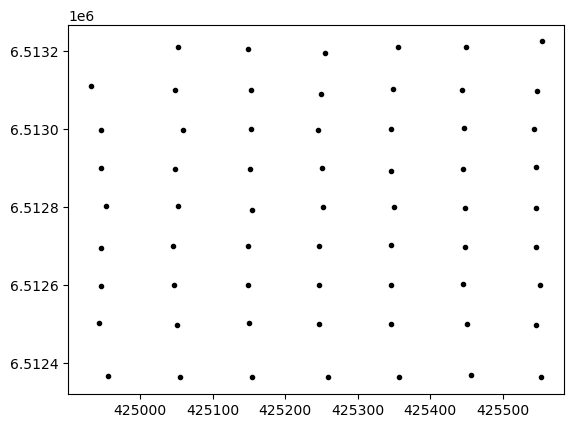

In [16]:
#topography_proj.plot()
plt.plot(easting, northing,'k.')

# Calculate topography graivty effect

We want to compute topography graivty effect use harmonica.DatasetAccessorPrismLayer.gravity, it generate a series of prism to represent the topography, and then do forward gravity calculation. In order to do that, we also need to define the density distribution first.

For every prism above the ellipsoid we will set the density of the upper crust (2670 kg/m3), while for each prism below it we will assign the density contrast equal to the density of the water (1040 kg/m3) minus the density of the upper crust.

You could change the density value to fit your local geology

In [12]:
density = np.where(topography_proj >= 0, 2670, 1040 - 2670)

prisms = hm.prism_layer(
    (topography_proj.easting, topography_proj.northing),
    surface=topography_proj,
    reference=0,
    properties={"density": density},
)
prisms

<xarray.Dataset> Size: 3MB
Dimensions:   (northing: 420, easting: 420)
Coordinates:
  * easting   (easting) float64 3kB 4.16e+05 4.16e+05 ... 4.35e+05 4.351e+05
  * northing  (northing) float64 3kB 6.501e+06 6.501e+06 ... 6.523e+06 6.523e+06
    top       (northing, easting) float32 706kB nan nan nan nan ... nan nan nan
    bottom    (northing, easting) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    density   (northing, easting) int32 706kB -1630 -1630 -1630 ... -1630 -1630
Attributes:
    coords_units:      meters
    properties_units:  SI

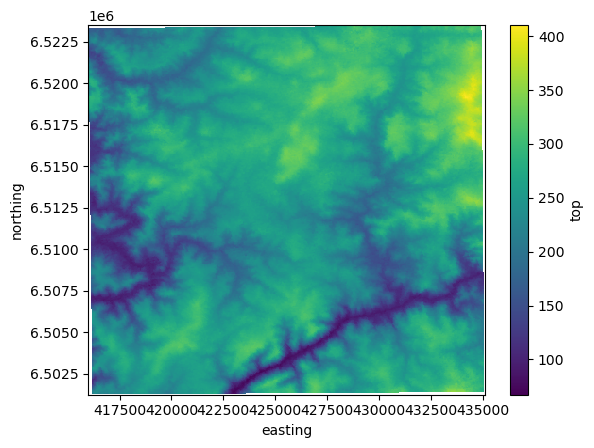

In [13]:
prisms.top.plot()

In [17]:
# Compute the terrain effect
terrain_effect = prisms.prism_layer.gravity(coordinates[0], field="g_z")

We do Similar things to far field topography

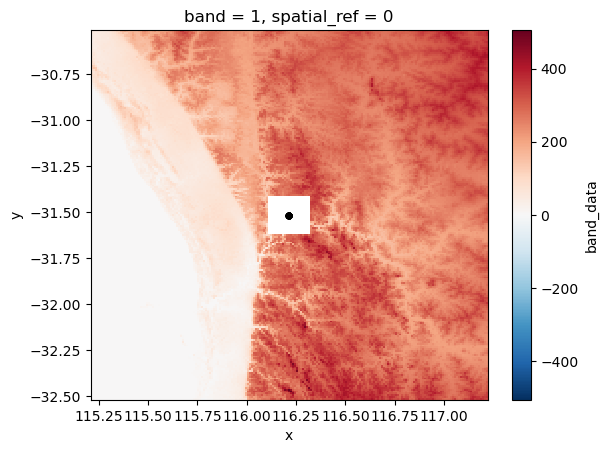

In [19]:
# Load the data array
topography_far = xr.load_dataarray('dem.tif')

# Get the region based on gravity data (Lon, Lat from the Data variable)
region = vd.get_region((Data.Lon, Data.Lat))

# Pad the region slightly for cropping purposes (1 degree padding, for example)
region_pad_large = vd.pad_region(region, pad=1)

# Select the middle box (region_pad_large) by slicing and set the values to NaN
topography = topography_far.copy()

topography = topography[0].sel(
    x=slice(region_pad_large[0], region_pad_large[1]),
    y=slice(region_pad_large[3], region_pad_large[2]),
)


topography_far_middle_nan = topography.copy()


topography_far_middle_nan.loc[dict(
    x=slice(region_pad[0], region_pad[1]), 
    y=slice(region_pad[3], region_pad[2])
)] = np.nan

# Plot the modified topography
topography_far_middle_nan.plot()
plt.plot(Data['Lon'], Data['Lat'], 'k.')
plt.show()


In [20]:
topography_far_middle_nan

<xarray.DataArray 'band_data' (y: 201, x: 201)> Size: 162kB
array([[ 45.,  45.,  46., ..., 346., 355., 370.],
       [ 45.,  48.,  43., ..., 357., 365., 388.],
       [ 39.,  40.,  41., ..., 362., 364., 380.],
       ...,
       [  0.,   0.,   0., ..., 323., 337., 347.],
       [  0.,   0.,   0., ..., 356., 350., 356.],
       [  0.,   0.,   0., ..., 358., 340., 332.]], dtype=float32)
Coordinates:
    band         int32 4B 1
  * x            (x) float64 2kB 115.2 115.2 115.2 115.2 ... 117.2 117.2 117.2
  * y            (y) float64 2kB -30.52 -30.52 -30.54 ... -32.49 -32.5 -32.52
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area

In [21]:
topography_proj = vd.project_grid(topography_far_middle_nan, projection, method="nearest")
topography_proj


density = np.where(topography_proj >= 0, 2670, 1040 - 2670)

prisms = hm.prism_layer(
    (topography_proj.easting, topography_proj.northing),
    surface=topography_proj,
    reference=0,
    properties={"density": density},
)
prisms

<xarray.Dataset> Size: 650kB
Dimensions:   (northing: 201, easting: 201)
Coordinates:
  * easting   (easting) float64 2kB 3.287e+05 3.297e+05 ... 5.197e+05 5.206e+05
  * northing  (northing) float64 2kB 6.401e+06 6.402e+06 ... 6.623e+06 6.624e+06
    top       (northing, easting) float32 162kB nan nan nan nan ... nan nan nan
    bottom    (northing, easting) float64 323kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Data variables:
    density   (northing, easting) int32 162kB -1630 -1630 -1630 ... -1630 -1630
Attributes:
    coords_units:      meters
    properties_units:  SI

In [22]:
# Compute the terrain effect
terrain_effect_far = prisms.prism_layer.gravity(coordinates, field="g_z")

In [23]:
# The topography-free gravity disturbance:
topo_free_disturbance = Data['Free Air Disturbance'] - terrain_effect - terrain_effect_far

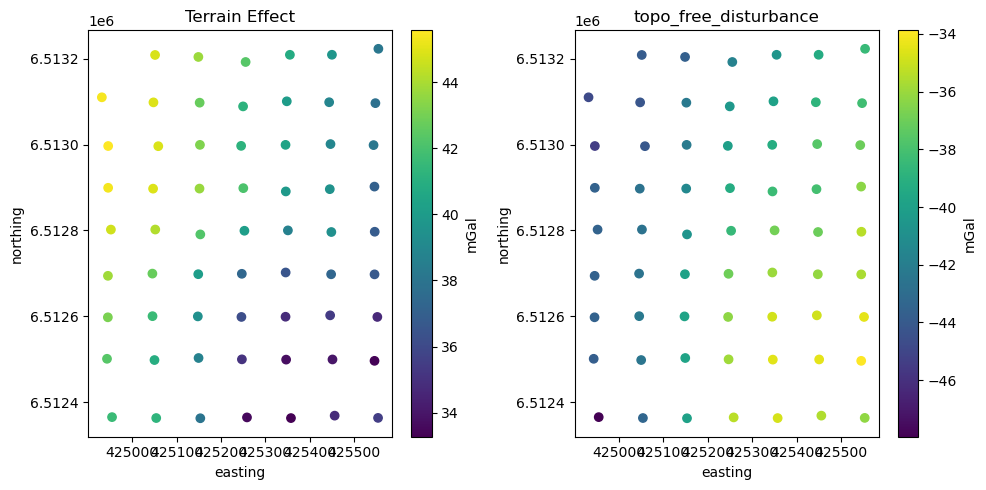

In [24]:
# Creating subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# First subplot: Drift over time
sc = axs[0].scatter(easting, northing, c=terrain_effect+terrain_effect_far, cmap='viridis')
axs[0].set_xlabel('easting')
axs[0].set_ylabel('northing')
axs[0].set_title("Terrain Effect")
plt.colorbar(sc, ax=axs[0], label='mGal')

# Second subplot: Drift for each locations
sc = axs[1].scatter(easting, northing, c=topo_free_disturbance, cmap='viridis')
axs[1].set_xlabel('easting')
axs[1].set_ylabel('northing')
axs[1].set_title("topo_free_disturbance")
plt.colorbar(sc, ax=axs[1], label='mGal')

# Display the plot
plt.tight_layout()
plt.show()

In [25]:
# Save the Data to a CSV file
data_array = np.column_stack((Data['Lon'], Data['Lat'], easting, northing, Data['Height_Ellipsoid'], Data['Total Gravity'], Data['Free Air Disturbance'],topo_free_disturbance))
df = pd.DataFrame(data_array, columns=['Lon', 'Lat', 'Easting', 'Northing', 'Height_Ellipsoid', 'Total Gravity', 'Free Air Disturbance','Topo Free Disturbance'])
df.to_csv('Topo_Free_Grav_CAGE_FIELD.csv', index=False)

In the next notebook, we will use the gravity data to run inversion !!!!!!!!!!!!!!!!!!!